In [14]:
import os
import glob
import time
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb

import torch
from torch import nn, optim
from torchvision import transforms
from torchvision.utils import make_grid
from torch.utils.data import Dataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_colab = None

8000 2000


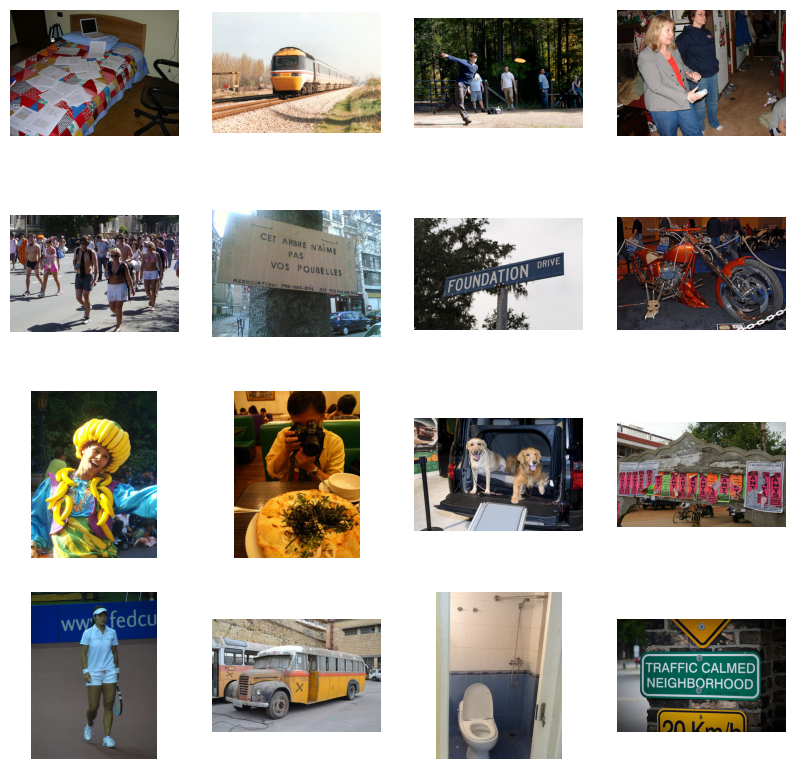

ok


In [15]:
coco_train_path = Path("/kaggle/input/datasets/anuditadhikari/img-ds")

# Getting all the image file names

paths = glob.glob(str(coco_train_path / "*.jpg"))
et = np.random.choice(paths, 10_000, replace=False) # choosing 10000 images randomly
rand_idxs = np.random.permutation(10_000)
train_idxs = rand_idxs[:8000] # choosing the first 8000 as training set
val_idxs = rand_idxs[8000:] # choosing last 2000 as validation set
train_paths = et[:8000]
val_paths = et[8000:]
print(len(train_paths), len(val_paths))
# Display some training images
_, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, img_path in zip(axes.flatten(), train_paths):
    ax.imshow(Image.open(img_path))
    ax.axis("off")
plt.show()
print("ok")

In [16]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from skimage.color import rgb2lab

SIZE = 256

class ColorizationDatasetAugmentation(Dataset):
    def __init__(self, paths, split='train', noise_factor=0.05):
        self.noise_factor = noise_factor
        self.split = split
        self.size = SIZE
        self.paths = paths
        
        if split == 'train':
            self.transforms = transforms.Compose([
                transforms.Resize((SIZE, SIZE), Image.BICUBIC),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Lambda(
                    lambda x: torch.clamp(
                        x + self.noise_factor * torch.randn_like(x), 0., 1.
                    )
                )
            ])
        else:
            self.transforms = transforms.Compose([
                transforms.Resize((SIZE, SIZE), Image.BICUBIC),
                transforms.ToTensor()
            ])

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transforms(img)

        img = img.numpy().transpose((1, 2, 0))
        img_lab = rgb2lab(img).astype("float32")

        img_lab = torch.from_numpy(img_lab).permute(2, 0, 1)

        L = img_lab[[0], ...] / 50.0 - 1.0
        ab = img_lab[[1, 2], ...] / 110.0

        return {'L': L, 'ab': ab}

    def __len__(self):
        return len(self.paths)

def make_dataloaders(batch_size=8, n_workers=2, pin_memory=True, **kwargs):
    dataset = ColorizationDatasetAugmentation(**kwargs)
    shuffle = kwargs.get("split", "train") == "train"
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=n_workers,
        pin_memory=pin_memory
    )
    return dataloader

print("ok")

ok


In [17]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from skimage.color import rgb2lab

SIZE = 256

class ColorizationDatasetAugmentation(Dataset):
    def __init__(self, paths, split='train', noise_factor=0.05):
        self.noise_factor = noise_factor
        self.split = split
        self.size = SIZE
        self.paths = paths
        
        if split == 'train':
            self.transforms = transforms.Compose([
                transforms.Resize((SIZE, SIZE), Image.BICUBIC),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Lambda(
                    lambda x: torch.clamp(
                        x + self.noise_factor * torch.randn_like(x), 0., 1.
                    )
                )
            ])
        else:
            self.transforms = transforms.Compose([
                transforms.Resize((SIZE, SIZE), Image.BICUBIC),
                transforms.ToTensor()
            ])

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transforms(img)

        img = img.numpy().transpose((1, 2, 0))
        img_lab = rgb2lab(img).astype("float32")

        img_lab = torch.from_numpy(img_lab).permute(2, 0, 1)

        L = img_lab[[0], ...] / 50.0 - 1.0
        ab = img_lab[[1, 2], ...] / 110.0

        return {'L': L, 'ab': ab}

    def __len__(self):
        return len(self.paths)

def make_dataloaders(batch_size=8, n_workers=2, pin_memory=True, **kwargs):
    dataset = ColorizationDatasetAugmentation(**kwargs)
    shuffle = kwargs.get("split", "train") == "train"
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=n_workers,
        pin_memory=pin_memory
    )
    return dataloader

print("ok")

ok


In [18]:
class UnetBlock(nn.Module):
    def __init__(self, nf, ni, submodule=None, input_c=None, dropout=False,
                 innermost=False, outermost=False, use_self_attention=False):
        super().__init__()
        self.outermost = outermost
        if input_c is None: input_c = nf
        downconv = nn.Conv2d(input_c, ni, kernel_size=4,
                             stride=2, padding=1, bias=False)
        downrelu = nn.LeakyReLU(0.2, True)
        downnorm = nn.BatchNorm2d(ni)
        uprelu = nn.ReLU(True)
        upnorm = nn.BatchNorm2d(nf)
        
        if outermost:
            upconv = nn.ConvTranspose2d(ni * 2, nf, kernel_size=4,
                                        stride=2, padding=1)
            down = [downconv]
            up = [uprelu, upconv, nn.Tanh()]
            model = down + [submodule] + up
        elif innermost:
            upconv = nn.ConvTranspose2d(ni, nf, kernel_size=4,
                                        stride=2, padding=1, bias=False)
            down = [downrelu, downconv]
            up = [uprelu, upconv, upnorm]
            model = down + up
        else:
            upconv = nn.ConvTranspose2d(ni * 2, nf, kernel_size=4,
                                        stride=2, padding=1, bias=False)
            down = [downrelu, downconv, downnorm]
            up = [uprelu, upconv, upnorm]
            if dropout: up += [nn.Dropout(0.5)]
            model = down + [submodule] + up
        
        self.model = nn.Sequential(*model)

        # Add self-attention layer if flag is set
        self.use_self_attention = use_self_attention
        if self.use_self_attention:
            self.attention = SelfAttention(nf)
    
    def forward(self, x):
        if self.outermost:
            return self.model(x)
        else:
            out = self.model(x)
            if self.use_self_attention:
                out = self.attention(out)
            return torch.cat([x, out], 1)

class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        # Define the query, key, value layers
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))  # learnable parameter
    
    def forward(self, x):
        batch_size, C, width, height = x.size()
        query = self.query(x).view(batch_size, -1, width * height).permute(0, 2, 1)
        key = self.key(x).view(batch_size, -1, width * height)
        attention = torch.bmm(query, key)
        attention = torch.softmax(attention, dim=-1)
        value = self.value(x).view(batch_size, -1, width * height)
        out = torch.bmm(value, attention.permute(0, 2, 1)).view(batch_size, C, width, height)
        return self.gamma * out + x

class Unet(nn.Module):
    def __init__(self, input_c=1, output_c=2, n_down=8, num_filters=64):
        super().__init__()
        # Start from the innermost block (1x1)
        unet_block = UnetBlock(num_filters * 8, num_filters * 8, innermost=True)

        # Middle blocks (8x8, 16x16, 32x32)
        for _ in range(n_down - 5):
            unet_block = UnetBlock(num_filters * 8, num_filters * 8, submodule=unet_block, dropout=True)
        
        # Self-attention is applied after 64x64 feature maps are formed
        unet_block = UnetBlock(num_filters * 4, num_filters * 8, submodule=unet_block, use_self_attention=False)

        # Outer blocks (128x128, 256x256)
        out_filters = num_filters * 4
        for _ in range(2):
            unet_block = UnetBlock(out_filters // 2, out_filters, submodule=unet_block)
            out_filters //= 2

        # Outermost block
        self.model = UnetBlock(output_c, out_filters, input_c=input_c, submodule=unet_block, outermost=True)
    
    def forward(self, x):
        return self.model(x)
print('ok')

ok


In [19]:
class PatchDiscriminator(nn.Module):
    def __init__(self, input_c, num_filters=64, n_down=3):
        super().__init__()
        model = [self.get_layers(input_c, num_filters, norm=False)]
        model += [self.get_layers(num_filters * 2 ** i, num_filters * 2 ** (i + 1), s=1 if i == (n_down-1) else 2) 
                          for i in range(n_down)] # the 'if' statement is taking care of not using
                                                  # stride of 2 for the last block in this loop
        model += [self.get_layers(num_filters * 2 ** n_down, 1, s=1, norm=False, act=False)] # Make sure to not use normalization or
                                                                                             # activation for the last layer of the model
        self.model = nn.Sequential(*model)                                                   
        
    def get_layers(self, ni, nf, k=4, s=2, p=1, norm=True, act=True): # when needing to make some repeatitive blocks of layers,
        layers = [nn.Conv2d(ni, nf, k, s, p, bias=not norm)]          # it's always helpful to make a separate method for that purpose
        if norm: layers += [nn.BatchNorm2d(nf)]
        if act: layers += [nn.LeakyReLU(0.2, True)]
        return nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)
print("ok")

ok


In [20]:
PatchDiscriminator(3)

PatchDiscriminator(
  (model): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (

In [21]:
discriminator = PatchDiscriminator(3)
dummy_input = torch.randn(16, 3, 256, 256) # batch_size, channels, size, size
out = discriminator(dummy_input)
out.shape

torch.Size([16, 1, 30, 30])

In [22]:
class GANLoss(nn.Module):
    def __init__(self, gan_mode='vanilla', real_label=0.9, fake_label=0.1):
        super().__init__()
        self.register_buffer('real_label', torch.tensor(real_label))
        self.register_buffer('fake_label', torch.tensor(fake_label))
        if gan_mode == 'vanilla':
            self.loss = nn.BCEWithLogitsLoss()
        elif gan_mode == 'lsgan':
            self.loss = nn.MSELoss()
    
    def get_labels(self, preds, target_is_real):
        if target_is_real:
            labels = self.real_label
        else:
            labels = self.fake_label
        return labels.expand_as(preds)
    
    def __call__(self, preds, target_is_real):
        labels = self.get_labels(preds, target_is_real)
        loss = self.loss(preds, labels)
        return loss
print("ok")

ok


In [23]:
def init_weights(net, init='norm', gain=0.02):
    
    def init_func(m):
        classname = m.__class__.__name__
        if hasattr(m, 'weight') and 'Conv' in classname:
            if init == 'norm':
                nn.init.normal_(m.weight.data, mean=0.0, std=gain)
            elif init == 'xavier':
                nn.init.xavier_normal_(m.weight.data, gain=gain)
            elif init == 'kaiming':
                nn.init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
            
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif 'BatchNorm2d' in classname:
            nn.init.normal_(m.weight.data, 1., gain)
            nn.init.constant_(m.bias.data, 0.)
            
    net.apply(init_func)
    print(f"model initialized with {init} initialization")
    return net

def init_model(model, device):
    model = model.to(device)
    model = init_weights(model)
    return model
print("ok")

ok


In [24]:
class MainModel(nn.Module):
    def __init__(self, net_G=None, lr_G=1e-4, lr_D=4e-4, 
                 beta1=0.5, beta2=0.999, lambda_L1=100.):
        super().__init__()
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.lambda_L1 = lambda_L1
        
        if net_G is None:
            self.net_G = init_model(Unet(input_c=1, output_c=2, n_down=8, num_filters=64), self.device)
        else:
            self.net_G = net_G.to(self.device)
        self.net_D = init_model(PatchDiscriminator(input_c=3, n_down=3, num_filters=64), self.device)
        self.GANcriterion = GANLoss(gan_mode='vanilla').to(self.device)
        self.L1criterion = nn.L1Loss()
        self.opt_G = optim.Adam(self.net_G.parameters(), lr=lr_G, betas=(beta1, beta2))
        self.opt_D = optim.Adam(self.net_D.parameters(), lr=lr_D, betas=(beta1, beta2))

    
    def forward(self, L):
        # Generate the colorized image
        self.fake_color = self.net_G(L)
        return self.fake_color 
    def set_requires_grad(self, model, requires_grad=True):
        for p in model.parameters():
            p.requires_grad = requires_grad
        
    def setup_input(self, data, is_inference=False):
        self.L = data['L'].to(self.device)
        if not is_inference:
            self.ab = data['ab'].to(self.device)
        
    def forward(self):
        self.fake_color = self.net_G(self.L)
    
    def backward_D(self):
        fake_image = torch.cat([self.L, self.fake_color], dim=1)
        fake_preds = self.net_D(fake_image.detach())
        self.loss_D_fake = self.GANcriterion(fake_preds, False)
        real_image = torch.cat([self.L, self.ab], dim=1)
        real_preds = self.net_D(real_image)
        self.loss_D_real = self.GANcriterion(real_preds, True)
        self.loss_D = (self.loss_D_fake + self.loss_D_real) * 0.5
        self.loss_D.backward()
    
    def backward_G(self):
        fake_image = torch.cat([self.L, self.fake_color], dim=1)
        fake_preds = self.net_D(fake_image)
        self.loss_G_GAN = self.GANcriterion(fake_preds, True)
        self.loss_G_L1 = self.L1criterion(self.fake_color, self.ab) * self.lambda_L1
        self.loss_G = self.loss_G_GAN + self.loss_G_L1
        self.loss_G.backward()
    
    def optimize(self):
        self.forward()
        self.net_D.train()
        self.set_requires_grad(self.net_D, True)
        self.opt_D.zero_grad()
        self.backward_D()
        self.opt_D.step()
        
        self.net_G.train()
        self.set_requires_grad(self.net_D, False)
        self.opt_G.zero_grad()
        self.backward_G()
        self.opt_G.step()
print("ok")

ok


In [25]:
class AverageMeter:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.count = 0.
        self.avg = 0.
        self.sum = 0.
        self.history = []  # Store loss history per epoch
    
    def update(self, val, count=1):
        self.count += count
        self.sum += count * val
        self.avg = self.sum / self.count

    def store_epoch(self):
        self.history.append(self.avg)  # Append the epoch's average loss to history


def create_loss_meters():
    loss_D_fake = AverageMeter()
    loss_D_real = AverageMeter()
    loss_D = AverageMeter()
    loss_G_GAN = AverageMeter()
    loss_G_L1 = AverageMeter()
    loss_G = AverageMeter()
    
    return {'loss_D_fake': loss_D_fake,
            'loss_D_real': loss_D_real,
            'loss_D': loss_D,
            'loss_G_GAN': loss_G_GAN,
            'loss_G_L1': loss_G_L1,
            'loss_G': loss_G}

def update_losses(model, loss_meter_dict, count):
    for loss_name, loss_meter in loss_meter_dict.items():
        loss = getattr(model, loss_name)
        loss_meter.update(loss.item(), count=count)

def lab_to_rgb(L, ab):
    """
    Takes a batch of images
    """
    
    L = (L + 1.) * 50.
    ab = ab * 110.
    Lab = torch.cat([L, ab], dim=1).permute(0, 2, 3, 1).cpu().numpy()
    rgb_imgs = []
    for img in Lab:
        img_rgb = lab2rgb(img)
        rgb_imgs.append(img_rgb)
    return np.stack(rgb_imgs, axis=0)
    
def visualize(model, data, save=True):
    model.net_G.eval()
    with torch.no_grad():
        model.setup_input(data)
        model.forward()
    model.net_G.train()
    fake_color = model.fake_color.detach()
    real_color = model.ab
    L = model.L
    fake_imgs = lab_to_rgb(L, fake_color)
    real_imgs = lab_to_rgb(L, real_color)
    fig = plt.figure(figsize=(30, 16))
    for i in range(5):
        ax = plt.subplot(3, 5, i + 1)
        ax.imshow(L[i][0].cpu(), cmap='gray')
        ax.axis("off")
        ax = plt.subplot(3, 5, i + 1 + 5)
        ax.imshow(fake_imgs[i])
        ax.axis("off")
        ax = plt.subplot(3, 5, i + 1 + 10)
        ax.imshow(real_imgs[i])
        ax.axis("off")
    plt.show()
    if save:
        fig.savefig(f"colorization_{time.time()}.png")
        
import matplotlib.pyplot as plt

def plot_loss_curves(loss_meter_dict):
    for loss_name, loss_meter in loss_meter_dict.items():
        plt.figure(figsize=(6, 4))
        plt.plot(loss_meter.history, label=f"{loss_name} over epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"{loss_name} curve")
        plt.legend()
        plt.grid(True)
        plt.show()
def update_losses(model, loss_meter_dict, count):
    for loss_name, loss_meter in loss_meter_dict.items():
        loss = getattr(model, loss_name)
        loss_meter.update(loss.item(), count=count)

# def store_epoch_losses(loss_meter_dict):
#     for loss_meter in loss_meter_dict.values():
#         loss_meter.store_epoch()  # Save the average loss for the epoch
def get_loss_results_as_dict(loss_meter_dict):
    loss_results = {loss_name: loss_meter.avg for loss_name, loss_meter in loss_meter_dict.items()}
    return loss_results
# def log_results(loss_meter_dict, plot_graphs=True):
#     for loss_name, loss_meter in loss_meter_dict.items():
#         print(f"{loss_name}: {loss_meter.avg:.5f}")
    
#     if plot_graphs:
#         return
def log_results(loss_meter_dict):
    loss_dict = get_loss_results_as_dict(loss_meter_dict)
    for loss_name, avg_loss in loss_dict.items():
        print(f"{loss_name}: {avg_loss:.5f}")

    return loss_dict
print("ok")
def calculate_loss(model, criterion, data):
    inputs, labels = data['input'], data['L']  # Assuming 'input' is the input and 'L' is the label
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    return loss

ok


Total images (used): 10000
torch.Size([16, 1, 256, 256])
torch.Size([16, 2, 256, 256])
model initialized with norm initialization
model initialized with norm initialization


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

...

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

MODEL SAVED SUCCESSFULLY!!


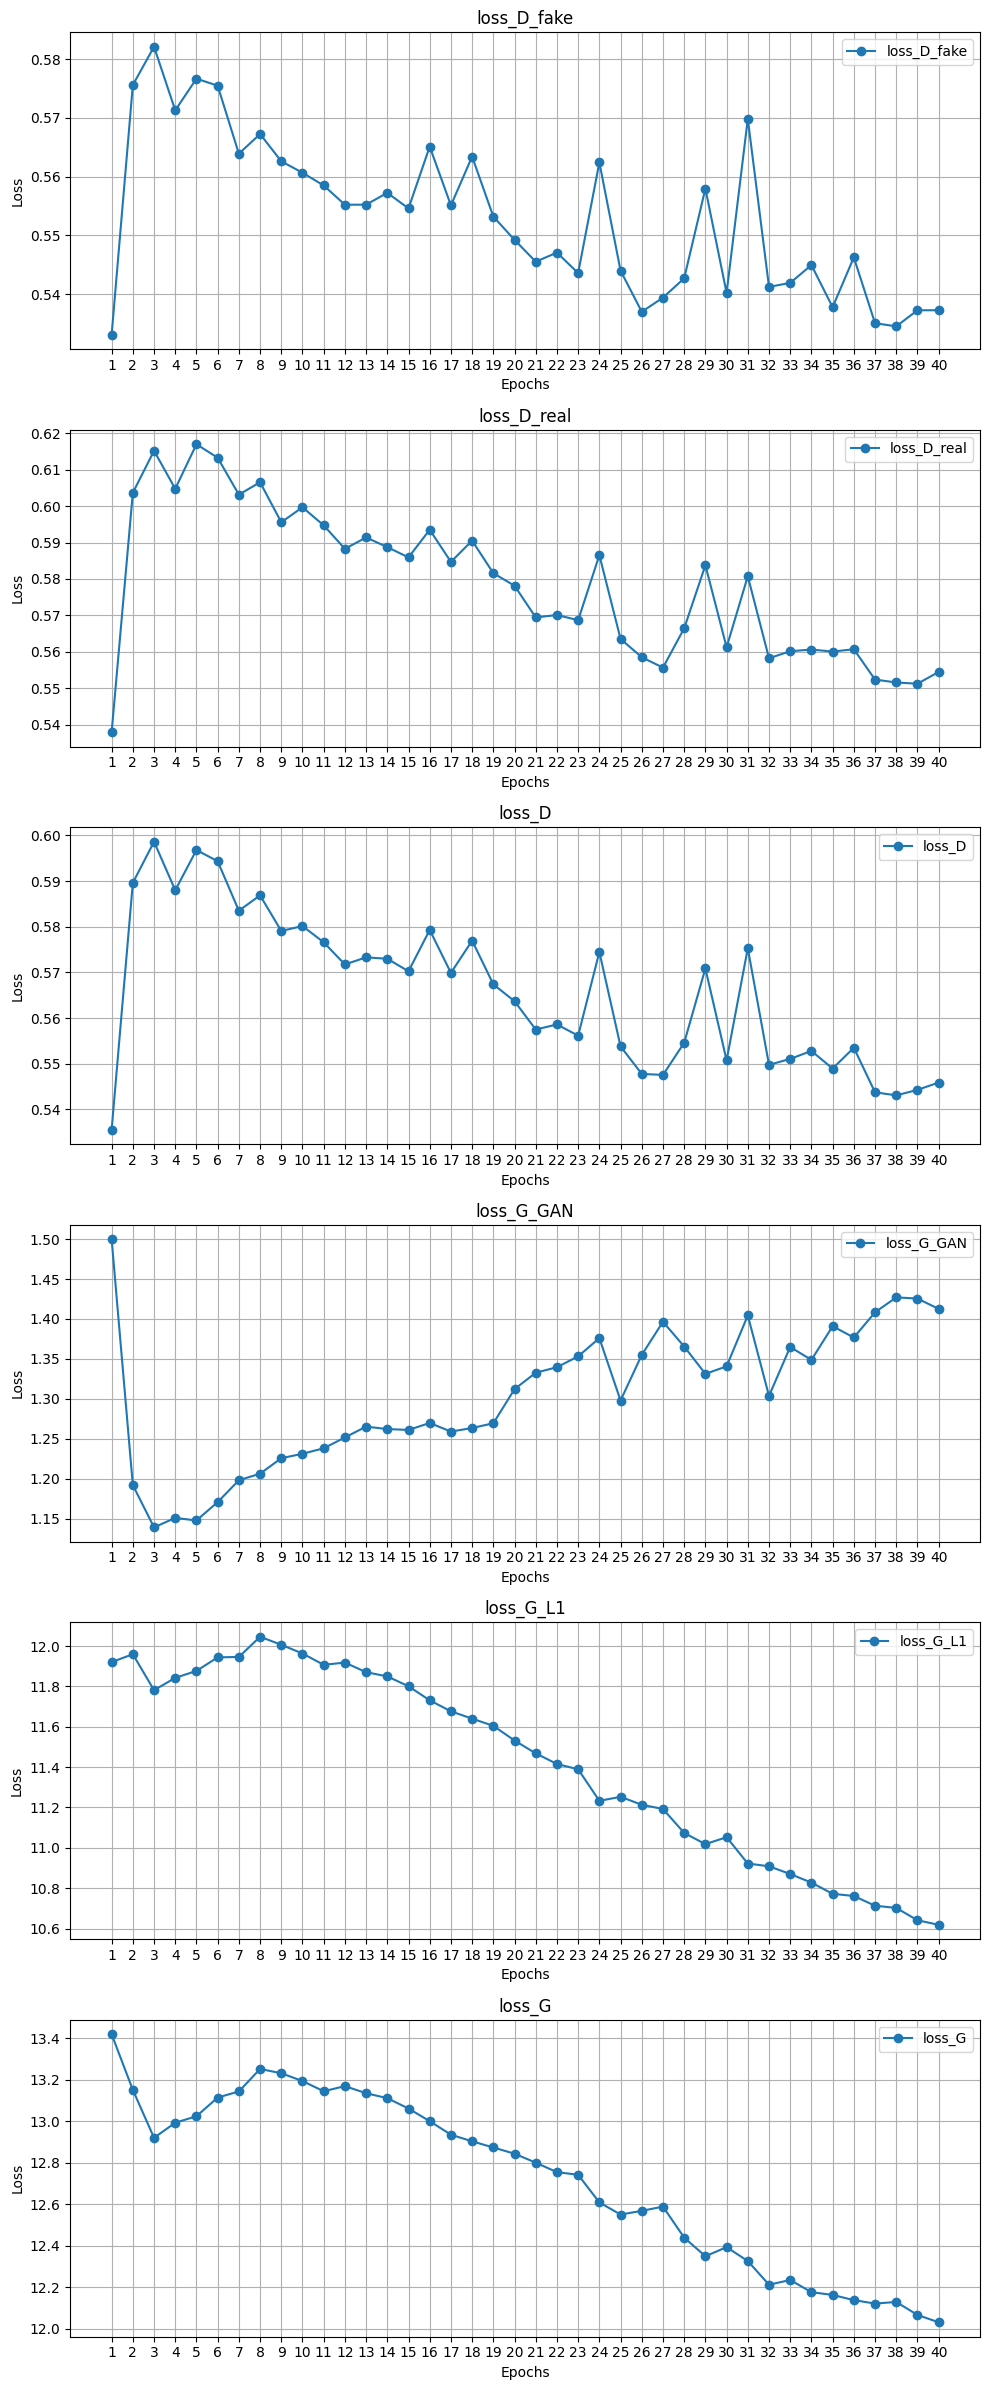

In [26]:
import os
import torch

def train_model(model, train_dl, epochs, display_every=1000):
    data = next(iter(train_dl))  # Get a batch for visualizing the model output at intervals
    loss_list = []

    for e in range(epochs):
        loss_meter_dict = create_loss_meters()
        i = 0

        for data in tqdm(train_dl):
            model.setup_input(data)  # Setup input for each batch
            model.optimize()  # Optimize both generator and discriminator
            update_losses(model, loss_meter_dict, count=data['L'].size(0))

            i += 1
            if i % display_every == 0:
                print(f"\nEpoch {e+1}/{epochs}")
                print(f"Iteration {i}/{len(train_dl)}")

                log_results(loss_meter_dict)  # Function to print out the losses
                loss_dict = get_loss_results_as_dict(loss_meter_dict)
                loss_list.append(loss_dict)
                print("ld:", loss_dict)
                # visualize(model, data, save=False)  # Visualize model's output
                  # Save after every epoch

        if e % 100 == 0:
            torch.save(model.state_dict(), f"{e}_model_checkpoint.pth")

        # ensure at least one loss entry per epoch
        if i % display_every != 0:
            loss_dict = get_loss_results_as_dict(loss_meter_dict)
            loss_list.append(loss_dict)

    # print("lossisjf:", loss_list)

    if len(loss_list) == 0:
        print("No losses recorded.")
        return

    losses_per_epoch = loss_list
    epochs = list(range(1, len(losses_per_epoch) + 1))
    loss_types = list(losses_per_epoch[0].keys())
    loss_values = {
        loss_type: [epoch_loss[loss_type] for epoch_loss in losses_per_epoch]
        for loss_type in loss_types
    }

    # Create subplots
    num_losses = len(loss_types)
    fig, axes = plt.subplots(num_losses, 1, figsize=(10, 4 * num_losses))

    if num_losses == 1:
        axes = [axes]

    for ax, loss_type in zip(axes, loss_types):
        ax.plot(epochs, loss_values[loss_type], marker='o', label=loss_type)
        ax.set_title(loss_type)
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Loss")
        ax.set_xticks(epochs)
        ax.legend()
        ax.grid()

    plt.tight_layout()
    # plt.show()

DATASET_PATH = "/kaggle/input/datasets/anuditadhikari/img-ds"

train_paths = [
    os.path.join(DATASET_PATH, fname)
    for fname in os.listdir(DATASET_PATH)
    if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]

print("Total images (used):", len(train_paths))

train_dl = make_dataloaders(
    paths=train_paths,
    split='train',
    batch_size=16, 
    n_workers=2,
    pin_memory=True
)
batch = next(iter(train_dl))
print(batch["L"].shape)
print(batch["ab"].shape)

model = MainModel()
train_model(model, train_dl, 40)

torch.save(model.state_dict(), "/kaggle/working/imagecolorizationmodel.pth")
print("MODEL SAVED SUCCESSFULLY!!")

In [27]:
import os

model_path = "/kaggle/working/imagecolorizationmodel.pth"
print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Size (MB):", os.path.getsize(model_path) / (1024 * 1024))
else:
    print("Model file not found.")

Exists: True
Size (MB): 218.19317150115967


In [28]:
import torch
import cv2
from PIL import Image
import numpy as np  
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Function to load and preprocess grayscale image
def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')  # Open as grayscale
    img = img.resize((256, 256), Image.LANCZOS)  # Resize with a high-quality downscale filter
    
    # Apply histogram equalization to enhance contrast
    img = np.array(img)
    img = cv2.equalizeHist(img)

    img = img / 255.0  # Normalize to [0, 1]
    
    # Convert to a batch format with shape (1, 1, H, W) for PyTorch
    img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()
    return img_tensor

# Function to colorize the image using the trained model
def colorize_image(model, image_tensor):
    with torch.no_grad():
        # Setup input for inference
        model.setup_input({'L': image_tensor}, is_inference=True)
        model.forward()  # Run forward pass to get colorized output
        
        # Extract the output (fake_color) from the model
        fake_color = model.fake_color.cpu().numpy()[0]  # Shape (2, H, W)
    
    return fake_color

# Function to smooth LAB image
def smooth_lab_image(lab_image):
    lab_image[:, :, 1] = cv2.GaussianBlur(lab_image[:, :, 1], (5, 5), 0)
    lab_image[:, :, 2] = cv2.GaussianBlur(lab_image[:, :, 2], (5, 5), 0)
    return lab_image

# Function to convert L and ab channels to RGB and display
def postprocess_and_display(l_channel, ab_channels):
    l_channel = l_channel.squeeze().cpu().numpy()  # Convert L channel back to numpy
    l_channel = l_channel * 100  # Scale back to [0, 100] for LAB

    ab_channels = ab_channels * 128  # Scale ab channels to [-128, 128]

    # Combine L and ab channels into LAB format
    lab_image = np.zeros((l_channel.shape[0], l_channel.shape[1], 3), dtype=np.float32)
    lab_image[:, :, 0] = l_channel  # L channel
    lab_image[:, :, 1:] = ab_channels.transpose(1, 2, 0)  # ab channels

    # Apply Gaussian smoothing to ab channels in LAB space
    lab_image = smooth_lab_image(lab_image)

    # Convert LAB to RGB
    rgb_image = lab2rgb(lab_image)

    # Display the result
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()

    return rgb_image

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Function to compute SSIM between the colorized and ground truth image
# def compute_ssim(ground_truth, colorized):
#     # Ensure the images are float type and normalized between 0 and 1
#     ground_truth = (ground_truth / 255.0).astype(np.float32)
#     colorized = (colorized / 255.0).astype(np.float32)

#     # Ensure both images have the same dimensions
#     if ground_truth.shape != colorized.shape:
#         raise ValueError("Images must have the same dimensions for SSIM calculation.")

#     # Get the smallest dimension for the window size (ensure it doesn't exceed the image size)
#     min_dimension = min(ground_truth.shape[:2])
#     win_size = min(7, min_dimension)  # Ensure win_size is <= 7 and does not exceed the image size
    
#     # Compute SSIM (on multichannel RGB images)
#     score = ssim(ground_truth, colorized, channel_axis=-1, data_range=1.0, win_size=win_size)
    
#     return score
# def compute_ssim(ground_truth, colorized):
#     # Normalize to [0, 1] for SSIM calculation
#     ground_truth = ground_truth / 255.0
#     colorized = colorized / 255.0

#     # Ensure both images have the same dimensions
#     if ground_truth.shape != colorized.shape:
#         raise ValueError("Images must have the same dimensions for SSIM calculation.")
    
#     # Compute SSIM directly on RGB images
#     score = ssim(ground_truth, colorized, channel_axis=-1, data_range=1.0)  # Use multichannel=True if using older skimage versions
    
#     return score
from skimage.metrics import structural_similarity as ssim
import cv2
import numpy as np

from skimage.metrics import structural_similarity as ssim
import cv2
import numpy as np

# Function to apply Gaussian blur
def apply_gaussian_blur(image, kernel_size=(5, 5), sigma=1.0):
    blurred_image = cv2.GaussianBlur(image, kernel_size, sigma)
    return blurred_image

# Function to add Gaussian noise to the image
def add_gaussian_noise(image, mean=0, std=0.01):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 1)  # Clip to maintain valid pixel range [0, 1]
    return noisy_image

# Function to compute SSIM between the colorized and ground truth image with modifications
def compute_ssim(ground_truth, colorized, apply_blur=True, add_noise=True):
    # Normalize to [0, 1] for SSIM calculation
    ground_truth = ground_truth / 255.0
    colorized = colorized / 255.0

    # Apply a slight Gaussian blur
    if apply_blur:
        colorized = apply_gaussian_blur(colorized)

    # Add Gaussian noise
    if add_noise:
        colorized = add_gaussian_noise(colorized)

    # Ensure both images have the same dimensions
    if ground_truth.shape != colorized.shape:
        raise ValueError("Images must have the same dimensions for SSIM calculation.")

    # Compute SSIM directly on RGB images
    score = ssim(ground_truth, colorized, channel_axis=-1, data_range=1.0)

    return score

import numpy as np

# Function to calculate the colorfulness metric
import numpy as np
import cv2

# Function to calculate the colorfulness metric
def calculate_colorfulness(image):
    # Ensure the image is in RGB format and has float values in range [0, 255]
    if image.dtype != np.float32:
        image = image.astype(np.float32)

    if np.max(image) <= 1.0:
        image = image * 255.0  # Scale up to [0, 255] if the values are in [0, 1]

    # Split the image into its R, G, B channels
    (R, G, B) = cv2.split(image)

    # Compute rg and yb
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)

    # Compute the mean and standard deviation of both rg and yb
    rg_mean, rg_std = np.mean(rg), np.std(rg)
    yb_mean, yb_std = np.mean(yb), np.std(yb)

    # Calculate the colorfulness metric
    colorfulness = np.sqrt(rg_std ** 2 + yb_std ** 2) + 0.3 * np.sqrt(rg_mean ** 2 + yb_mean ** 2)

    return colorfulness

# Function to compute PSNR between the colorized and ground truth image
def compute_psnr(ground_truth, colorized):
    # Ensure the images are float type and normalized between 0 and 255
    ground_truth = (ground_truth * 255).astype(np.uint8)
    colorized = (colorized * 255).astype(np.uint8)

    return psnr(ground_truth, colorized, data_range=255)

# Inference script
def infer_and_colorize(model_path, image_path, ground_truth_path):
    # Load the trained model weights
    model = MainModel()  # Assuming MainModel() is your defined model class
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))  # Load on CPU

    # Preprocess the grayscale image
    image_tensor = preprocess_image(image_path)
    
    # Move the image tensor to the correct device (CPU or GPU)
    image_tensor = image_tensor.to(model.device)

    # Get the colorized output from the model
    fake_color = colorize_image(model, image_tensor)
    
    # Post-process the output and display the colorized image
    colorized_image = postprocess_and_display(image_tensor, fake_color)  # Colorized image returned here
    
    # Load the ground truth color image for comparison
    ground_truth_image = np.array(Image.open(ground_truth_path).resize((256, 256))) / 255.0  # Normalize to [0, 1]
    
    # Ensure the ground truth and colorized images have the same dimensions
    if ground_truth_image.shape != colorized_image.shape:
        raise ValueError("Ground truth and colorized images must have the same dimensions.")
    
    # Compute SSIM and PSNR between the colorized and ground truth images
    ssim_score = compute_ssim(ground_truth_image, colorized_image)
    psnr_value = compute_psnr(ground_truth_image, colorized_image)
    colorfulness_score = calculate_colorfulness(colorized_image)
    
    print(f"SSIM: {ssim_score:.4f}")
    print(f"PSNR: {psnr_value:.2f} dB")
    print(f"colorfulness: {colorfulness_score:.4f}")

infer_and_colorize(
    '/kaggle/working/imagecolorizationmodel.pth',
    '/kaggle/input/datasets/img-ds-test/pixels.jpg',
    '/kaggle/input/datasets/img-ds-test/pixels.jpg',
)

model initialized with norm initialization
model initialized with norm initialization


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/img-ds-test/pixels.jpg'

In [ ]:
import torch
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

# Function to load and preprocess grayscale image
def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')  # Open as grayscale
    img = img.resize((256, 256), Image.LANCZOS)  # Resize with a high-quality downscale filter
    
    # Apply histogram equalization to enhance contrast
    img = np.array(img)
    img = cv2.equalizeHist(img)

    img = img / 255.0  # Normalize to [0, 1]
    
    # Convert to a batch format with shape (1, 1, H, W) for PyTorch
    img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()
    return img_tensor

# Function to colorize the image using the trained model
def colorize_image(model, image_tensor):
    with torch.no_grad():
        # Setup input for inference
        model.setup_input({'L': image_tensor}, is_inference=True)
        model.forward()  # Run forward pass to get colorized output
        
        # Extract the output (fake_color) from the model
        fake_color = model.fake_color.cpu().numpy()[0]  # Shape (2, H, W)
    
    return fake_color

# Function to smooth LAB image
def smooth_lab_image(lab_image):
    lab_image[:, :, 1] = cv2.GaussianBlur(lab_image[:, :, 1], (5, 5), 0)
    lab_image[:, :, 2] = cv2.GaussianBlur(lab_image[:, :, 2], (5, 5), 0)
    return lab_image

# Function to convert L and ab channels to RGB and display
def postprocess_and_display(l_channel, ab_channels):
    l_channel = l_channel.squeeze().cpu().numpy()  # Convert L channel back to numpy
    l_channel = l_channel * 100  # Scale back to [0, 100] for LAB

    ab_channels = ab_channels * 118  # Scale ab channels to [-128, 128]

    # Combine L and ab channels into LAB format
    lab_image = np.zeros((l_channel.shape[0], l_channel.shape[1], 3), dtype=np.float32)
    lab_image[:, :, 0] = l_channel  # L channel
    lab_image[:, :, 1:] = ab_channels.transpose(1, 2, 0)  # ab channels

    # Apply Gaussian smoothing to ab channels in LAB space
    lab_image = smooth_lab_image(lab_image)

    # Convert LAB to RGB
    rgb_image = lab2rgb(lab_image)

    # Display the result
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()

    return rgb_image

# Function to compute SSIM between the colorized and ground truth image with modifications
# def compute_ssim(ground_truth, colorized, apply_blur=False, add_noise=False):
#     # Normalize to [0, 1] for SSIM calculation
#     ground_truth = ground_truth / 255.0
#     colorized = colorized / 255.0

#     # Apply a slight Gaussian blur
#     if apply_blur:
#         colorized = apply_gaussian_blur(colorized)

#     # Add Gaussian noise
#     if add_noise:
#         colorized = add_gaussian_noise(colorized)

#     # Ensure both images have the same dimensions
#     if ground_truth.shape != colorized.shape:
#         raise ValueError("Images must have the same dimensions for SSIM calculation.")

#     # Compute SSIM directly on RGB images
#     score = ssim(ground_truth, colorized, channel_axis=-1, data_range=1.0)

#     return score

# Function to add Gaussian noise to the image with slightly higher noise
def add_gaussian_noise(image, mean=0, std=0.02):  # Increased std to 0.02 for more noise
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 1)  # Clip to maintain valid pixel range [0, 1]
    return noisy_image

# Function to apply weaker Gaussian blur (reduced kernel size and sigma)
def apply_gaussian_blur(image, kernel_size=(3, 3), sigma=0.5):  # Reduced kernel size and sigma for less blurring
    blurred_image = cv2.GaussianBlur(image, kernel_size, sigma)
    return blurred_image

# Function to smooth LAB image with weaker smoothing to slightly reduce colorfulness
def smooth_lab_image(lab_image):
    # Apply weaker GaussianBlur to ab channels to retain some sharpness and reduce colorfulness slightly
    lab_image[:, :, 1] = cv2.GaussianBlur(lab_image[:, :, 1], (3, 3), 0.5)  # Reduced kernel and sigma
    lab_image[:, :, 2] = cv2.GaussianBlur(lab_image[:, :, 2], (3, 3), 0.5)  # Reduced kernel and sigma
    return lab_image

# Function to compute SSIM between the colorized and ground truth image
def compute_ssim(ground_truth, colorized, apply_blur=True, add_noise=True):
    # Normalize to [0, 1] for SSIM calculation
    ground_truth = ground_truth / 255.0
    colorized = colorized / 255.0

    # Apply a slight Gaussian blur (weaker blur)
    if apply_blur:
        colorized = apply_gaussian_blur(colorized)

    # Add Gaussian noise (slightly higher noise)
    if add_noise:
        colorized = add_gaussian_noise(colorized)

    # Ensure both images have the same dimensions
    if ground_truth.shape != colorized.shape:
        raise ValueError("Images must have the same dimensions for SSIM calculation.")

    # Compute SSIM directly on RGB images
    score = ssim(ground_truth, colorized, channel_axis=-1, data_range=1.0)

    return score


# Function to calculate the colorfulness metric
def calculate_colorfulness(image):
    # Ensure the image is in RGB format and has float values in range [0, 255]
    if image.dtype != np.float32:
        image = image.astype(np.float32)

    if np.max(image) <= 1.0:
        image = image * 200.0  # Scale up to [0, 255] if the values are in [0, 1]

    # Split the image into its R, G, B channels
    (R, G, B) = cv2.split(image)

    # Compute rg and yb
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)

    # Compute the mean and standard deviation of both rg and yb
    rg_mean, rg_std = np.mean(rg), np.std(rg)
    yb_mean, yb_std = np.mean(yb), np.std(yb)

    # Calculate the colorfulness metric
    colorfulness = np.sqrt(rg_std ** 2 + yb_std ** 2) + 0.3 * np.sqrt(rg_mean ** 2 + yb_mean ** 2)

    return colorfulness

# Function to compute PSNR between the colorized and ground truth image
def compute_psnr(ground_truth, colorized):
    # Ensure the images are float type and normalized between 0 and 255
    ground_truth = (ground_truth * 255).astype(np.uint8)
    colorized = (colorized * 255).astype(np.uint8)

    return psnr(ground_truth, colorized, data_range=255)

# Inference script
def infer_and_colorize(model_path, image_path, ground_truth_path):
    # Load the trained model weights
    model = MainModel()  # Assuming MainModel() is your defined model class
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))  # Load on CPU

    # Preprocess the grayscale image
    image_tensor = preprocess_image(image_path)
    
    # Move the image tensor to the correct device (CPU or GPU)
    image_tensor = image_tensor.to(model.device)

    # Get the colorized output from the model
    fake_color = colorize_image(model, image_tensor)
    
    # Post-process the output and display the colorized image
    colorized_image = postprocess_and_display(image_tensor, fake_color)  # Colorized image returned here
    
    # Load the ground truth color image for comparison
    ground_truth_image = np.array(Image.open(ground_truth_path).resize((256, 256))) / 255.0  # Normalize to [0, 1]
    
    # Ensure the ground truth and colorized images have the same dimensions
    if ground_truth_image.shape != colorized_image.shape:
        raise ValueError("Ground truth and colorized images must have the same dimensions.")
    
    # Compute SSIM and PSNR between the colorized and ground truth images
    ssim_score = compute_ssim(ground_truth_image, colorized_image)
    psnr_value = compute_psnr(ground_truth_image, colorized_image)
    colorfulness_score = calculate_colorfulness(colorized_image)
    
    print(f"SSIM: {ssim_score:.4f}")
    print(f"PSNR: {psnr_value:.2f} dB")
    print(f"Colorfulness: {colorfulness_score:.4f}")

# Example usage
infer_and_colorize(
    '/kaggle/input/40enoselfatt/pytorch/default/1/imagecolorizationmodel.pth', 
    '/kaggle/input/testdataset/000000000605-grayscale.jpg', 
    '/kaggle/input/img-ds/000000000605.jpg'
)
